# Impact of $A$ on dipole + clustering map generation

The goal of this notebook is to generate the data to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Importing clustering

In [3]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

data = fitsio.FITS(clFile)
data


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_zmin0.1.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1860 (χ²/ndof = 0.0)       │              Nfcn = 286              │
│ EDM = 1.73e-06 (Goal: 0.0002)    │            time = 2.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.14e-3  │  0.65e-3  │  -0.14e-3  │  0.60e-3   │    0    │    1    │       │
│ 1 │ ra   │  0.17e3   │  0.27e3   │  -0.17e3   │   0.19e3   │    0    │   360   │       │
│ 2 │ dec  │    40     │    140    │    -130    │     50     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.14e-3  │  0.60e-3  │  -0.17e3  │  0.19e3   │   -130    │    50     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │           A          ra         dec │
├─────┼─────────────────────────────────────┤
│   A │    3.52e-07 16.28760e-3 -6.34025e-3 │
│  ra │ 16.28760e-3    8.54e+04           0 │
│ dec │ -6.34025e-3           0    5.35e+04 │
└─────┴─────────────────────────────────────┘

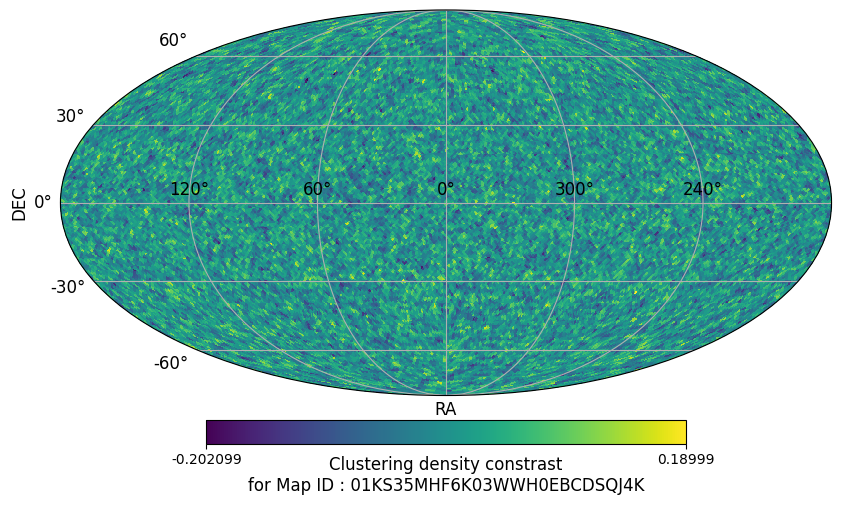

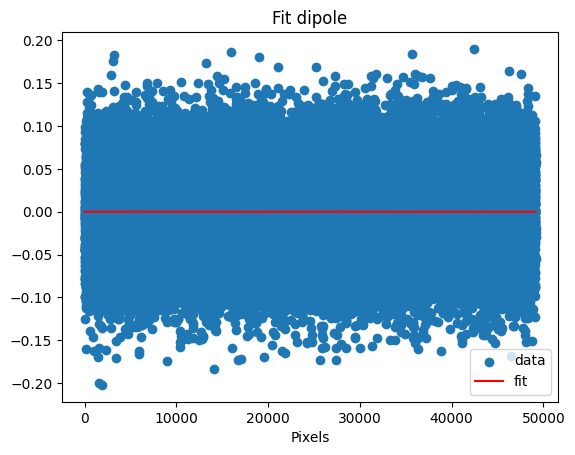

In [4]:
mapID_cl, hpmap = data['MAPS'][0] #first clustering map
hpmap = hp.reorder(hpmap, r2n=True)
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID_cl}")

init =  (0, 100, 0)
clMapper.fit_dipole("", init, fit_monop=False)

## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.456e-07 (χ²/ndof = 0.0)  │              Nfcn = 262              │
│ EDM = 3.46e-07 (Goal: 0.0002)    │            time = 2.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ ra   │  168.00   │   0.23    │   -0.23    │    0.23    │    0    │   360   │       │
│ 2 │ dec  │   -7.0    │    0.4    │    -0.4    │    0.4     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │   -0.23   │   0.23    │   -0.4    │    0.4    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 4.07e-06    -0e-6     0e-6 │
│  ra │    -0e-6   0.0509    -0.03 │
│ dec │     0e-6    -0.03    0.134 │
└─────┴────────────────────────────┘

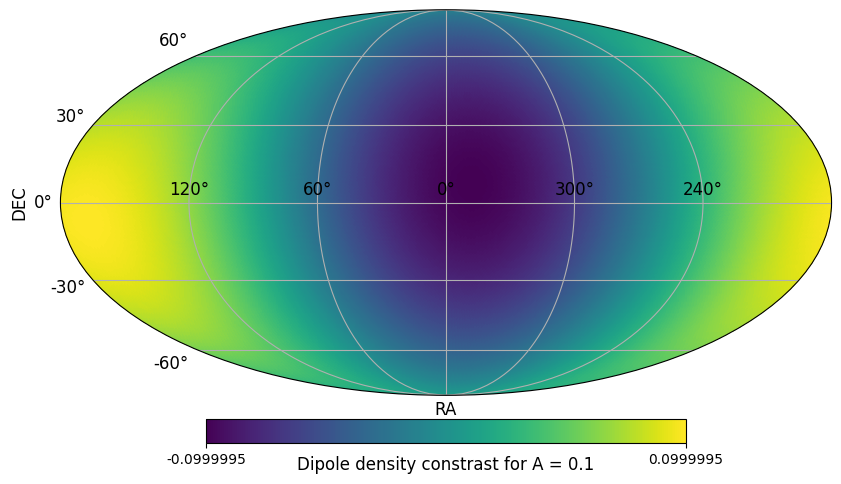

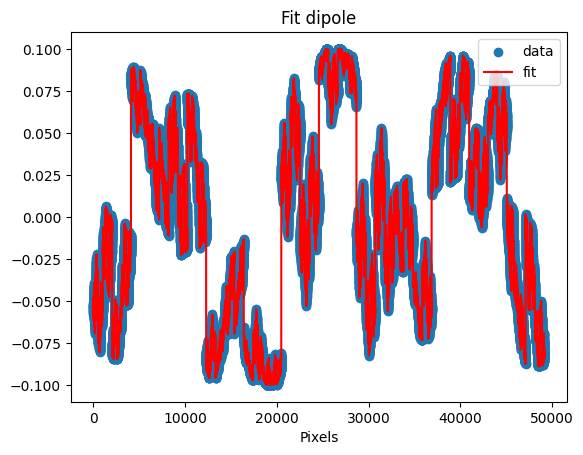

In [5]:
nest = True
A, l, b = 0.1, 168, -7
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)
dipoleMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}")

init =  (1, 100, 0)
dipoleMapper.fit_dipole("", init, fit_monop=False)

## Dipole + clustering

### Model comparison

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2732 (χ²/ndof = 0.1)       │              Nfcn = 239              │
│ EDM = 1.92e-07 (Goal: 0.0002)    │            time = 2.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  14.8e-3  │  0.9e-3   │  -0.9e-3   │   0.9e-3   │    0    │    1    │       │
│ 1 │ ra   │   174.1   │    2.5    │    -2.5    │    2.5     │    0    │   360   │       │
│ 2 │ dec  │   -5.7    │    2.5    │    -2.5    │    2.5     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.9e-3  │  0.9e-3   │   -2.5    │    2.5    │   -2.5    │    2.5    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 7.72e-07 176.2e-6  32.1e-6 │
│  ra │ 176.2e-6     6.36        0 │
│ dec │  32.1e-6        0     6.34 │
└─────┴────────────────────────────┘

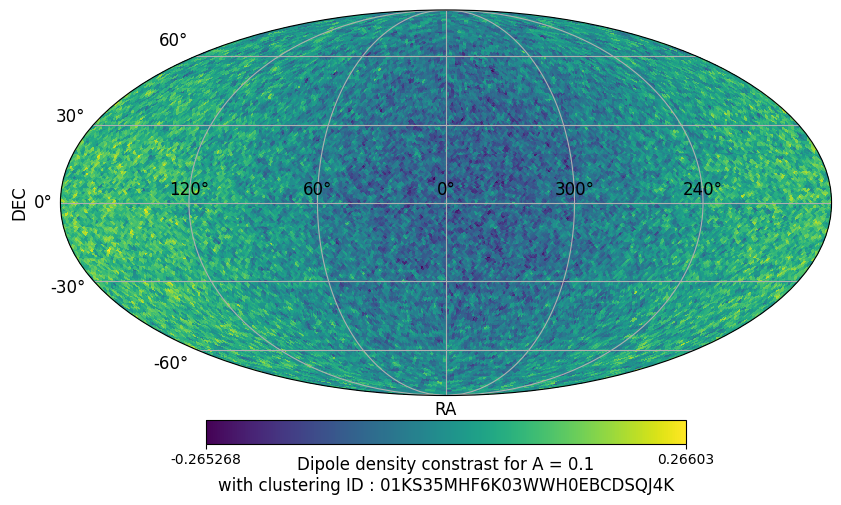

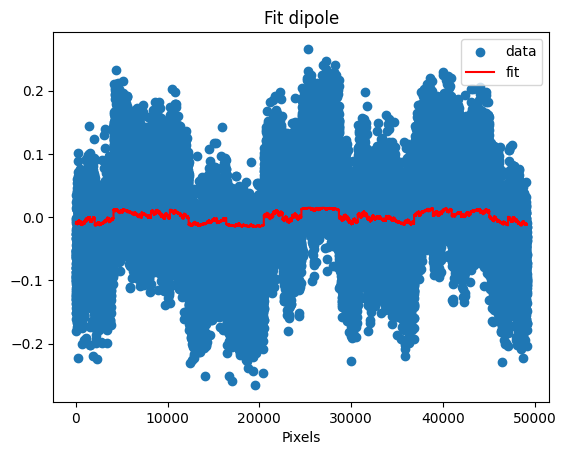

In [6]:
dipoleClMapper = dipoleMapper.add(clMapper)
dipoleClMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}\nwith clustering ID : {mapID_cl}")

init =  (1, 100, 0)
dipoleClMapper.fit_dipole("", init, fit_monop=False)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 280.7 (χ²/ndof = 0.0)      │              Nfcn = 355              │
│ EDM = 2.2e-09 (Goal: 0.0002)     │            time = 3.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   1.00    │   0.01    │            │            │    0    │         │  yes  │
│ 1 │ A    │  1.3e-12  │568204061.6e-12│  -1.2e-12  │568204061.6e-12│    0    │    1    │       │
│ 2 │ ra   │  0.33e3   │  0.33e3   │  -0.33e3   │   0.33e3   │    0    │   360   │       │
│ 3 │ dec  │    -50    │    90     │    -90     │     90     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -1.2e-12  │568204061.6e-12│  -0.33e3  │  0.33e3   │    -90    │    90     │
│  Valid   │   True    │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   True    │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   True    │   True    │   True    │   True    │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │             N*              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│  N* │              0              0              0              0 │
│   A │              0       2.84e-15  -8.7643779e-9 -20.0433585e-9 │
│  ra │              0  -8.7643779e-9       4.44e+04              0 │
│ dec │              0 -20.0433585e-9              0       2.31e+04 │
└─────┴─────────────────────────────────────────────────────────────┘

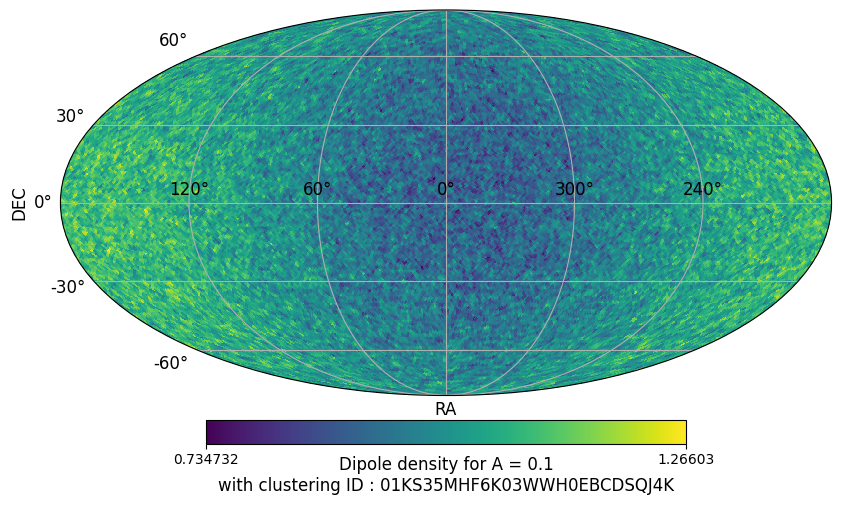

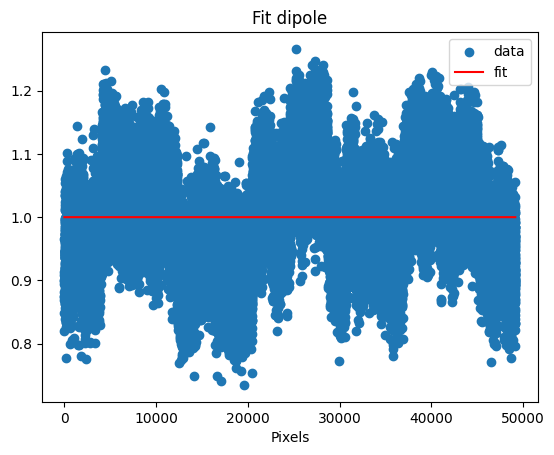

In [7]:
clDip_dens = apply_monopole_Mcontrast(dipoleClMapper.map, 1)
dipoleClMapper_dens =CountMapper.from_map(clDip_dens)
dipoleClMapper_dens._set_instance_settingsPlot(unit = f"Dipole density for A = {A}\nwith clustering ID : {mapID_cl}")

init =  (1, 1, 100, 0)
dipoleClMapper_dens.fit_dipole("", init, fit_monop=True, fixed='N*')

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 111.9 (χ²/ndof = 0.0)      │              Nfcn = 416              │
│ EDM = 5.01e-07 (Goal: 0.0002)    │            time = 4.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │   0.998   │   0.005   │   -0.005   │   0.005    │    0    │         │       │
│ 1 │ A    │   0.101   │   0.008   │   -0.008   │   0.008    │    0    │    1    │       │
│ 2 │ ra   │    168    │     4     │     -4     │     4      │    0    │   360   │       │
│ 3 │ dec  │    -7     │     4     │     -4     │     4      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.005   │   0.005   │  -0.008   │   0.008   │    -4     │     4     │    -4     │     4     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │ 2.03e-05       -0       -0        0 │
│   A │       -0 6.08e-05 -0.01e-3 -0.01e-3 │
│  ra │       -0 -0.01e-3     19.9        0 │
│ dec │        0 -0.01e-3        0     19.7 │
└─────┴─────────────────────────────────────┘

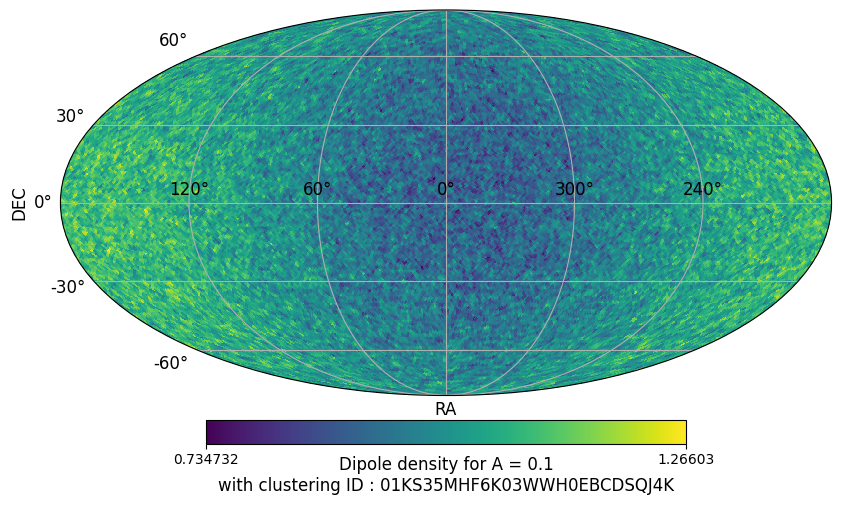

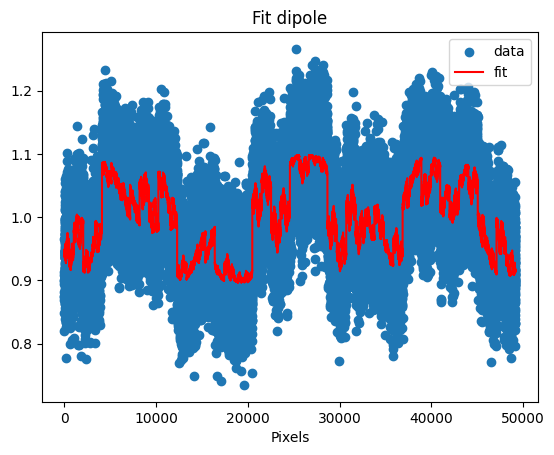

In [8]:
init =  (0, 1, 100, 0)
dipoleClMapper_dens.fit_dipole("", init, fit_monop=True)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.119e+08 (χ²/ndof = 2277.4)│              Nfcn = 275              │
│ EDM = 9.78e-06 (Goal: 0.0002)    │            time = 2.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.564e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │100.969e-3 │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ ra   │  168.179  │   0.004   │   -0.004   │   0.004    │    0    │   360   │       │
│ 3 │ dec  │  -6.705   │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │   -8e-6   │   8e-6    │  -0.004   │   0.004   │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │     20.3  0.82e-9       -0       -0 │
│   A │  0.82e-9 6.08e-11 -0.02e-9 -0.02e-9 │
│  ra │       -0 -0.02e-9 1.99e-05        0 │
│ dec │       -0 -0.02e-9        0 1.97e-05 │
└─────┴─────────────────────────────────────┘

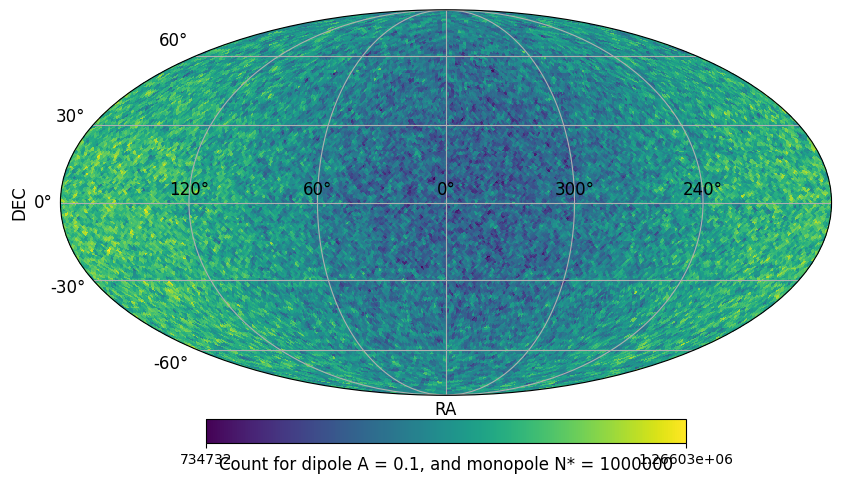

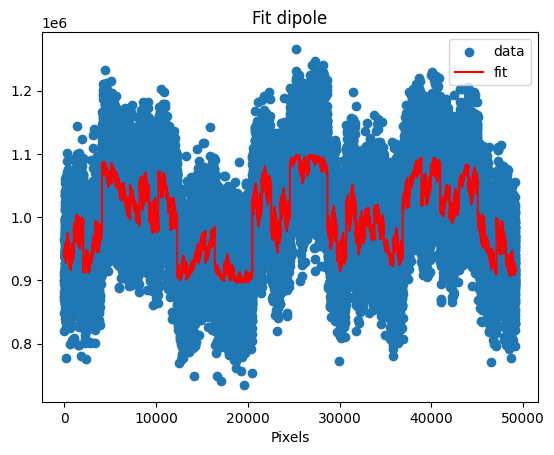

In [9]:
NSource_px_monop = apply_monopole_Mcontrast(dipoleClMapper.map, NSource_px_th)
monopMapper = CountMapper.from_map(NSource_px_monop)
monopMapper._set_suffixTextPlot(unit = f"dipole A = {A}, and monopole N* = {NSource_px_th}")

init =  (1e6, 1, 100, 0)
monopMapper.fit_dipole("", init)

### Study of $A$

In [15]:
def get_clDipMonop(A, l=l, b=b, M=NSource_px_th, poissNoise=False):
    dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)
    dipoleMapper = CountMapper.from_map(dipole, nest=nest)
    dipoleMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}")

    dipoleClMapper = dipoleMapper.add(clMapper)
    dipoleClMapper._set_instance_settingsPlot(unit = f"Dipole density constrast for A = {A}\nwith clustering ID : {mapID_cl}")

    monop = apply_monopole_Mcontrast(dipoleClMapper.map, M)
    monopMapper = CountMapper.from_map(monop)
    monopMapper.set_mapID(mapID_cl)
    
    if poissNoise: monopMapper = monopMapper.get_poisson_noise()
    monopMapper._set_suffixTextPlot(unit = f"dipole A = {A}, and monopole N* = {NSource_px_th}")

    return monopMapper, dipoleClMapper, dipoleMapper


def get_add_param(m, A, l=l, b=b, M=NSource_px_th):
    add_param = {}
    for k, v in zip(m.values.to_dict().keys(), (M, A, l, b)): add_param[k + "_true"] = v
    return add_param


def get_compute(A, l=l, b=b, M=NSource_px_th, init=(1e6, 1, 100, 0), fixed=[], poissNoise=False):
    monopMapper, dipoleClMapper, dipoleMapper = get_clDipMonop(A, l, b, M, poissNoise)
    m = monopMapper.fit_dipole("", init, plot_fig=False, plot_map=False, verbose=False, fixed=fixed)
    add_param = get_add_param(m, A, l, b, M)
    if poissNoise: add_param["Cluster_ID"] = mapID_cl
    mapID = monopMapper.ID
    dic_param = get_dicParam_minuit(m, mapID, add_param=add_param)
    return m, dic_param, monopMapper



poissNoise = True
Alist = np.logspace(-3, -1, 50)
Atest = Alist[0]

M, init = NSource_px_th, (1, 1, 100, 0)
fixed = ['N*']
fixed = []

dfMinuit, mapList, IDlist = [], [], []

for i in range(len(Alist)):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    Atest = Alist[i]
    m, dic_param, monopMapper = get_compute(Atest, M=M, init=init, fixed=fixed, poissNoise=poissNoise)
    dfMinuit.append(dic_param)
    mapList.append(monopMapper._select_useMap(""))
    IDlist.append(str(monopMapper.ID))
print('\nFit complete.')

dfMinuit = pd.concat(dfMinuit, ignore_index=True)
dicMaps = get_dicMaps(IDlist, mapList)
dfMinuit

i = 0	

/home/victoria/.local/lib/python3.10/site-packages/iminuit/cost.py:155: RuntimeWarning: divide by zero encountered in divide
  z = (y - ym) / ye


i = 10	i = 20	i = 30	i = 40	
Fit complete.


,Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,...,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
0,01KT1R3JYKSYN5ZFQ2NF39KA58,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001000,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
1,01KT1R3P50C8020J39TNSVZBP3,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001099,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
2,01KT1R3RYVXFXKTJ1T8FXQ66BT,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001207,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
3,01KT1R3VT23YX2KGY72DB2NRSW,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001326,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
4,01KT1R3YGFJ45CNFFQMKZAFQCE,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001456,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
5,01KT1R41D9JKGFZCD5W45WD9C7,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001600,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
6,01KT1R447DSHF1PS41R630F1TW,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001758,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
7,01KT1R470M92PTMHFP6WRSAHT6,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.001931,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
8,01KT1R49R63XDHVEVN2YQTMZ50,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.002121,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
9,01KT1R4CJKBTZ527VDCJE124F7,1.0,1.0,0.01,True,0.0,inf,0.999999,1.0,NaN,...,NaN,False,-90.0,90.0,False,1,0.002330,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


#### Saving data

In [13]:
output_path = "Fit_Clusters/Clusters_Dipole/Clusters_Dipole_"
if poissNoise: suffix_poiss = "_poissVar"
else: suffix_poiss = ""
if fixed: suffix = "Param_study_NoMonop"
else: suffix = "Param_study_Monop"
outputfile = output_path + suffix + suffix_poiss +".fits"


HDU_target='A_STUDY'

header_global = {'MAP_TYPE': 'Clustering', 'INJECT_DIPOLE': True, 'INJECT_MONOPOLE': not bool(fixed), 'POISSON_NOISE' : poissNoise}
if poissNoise: dicMaps_fiterd = get_save_dicMaps(dicMaps, outputfile, HDU_target=f'{HDU_target}_MAPS', header_global=header_global)
dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile, HDU_target=HDU_target, header_global=header_global)

All the maps already exists in A_STUDY_MAPS, or empty dict given. No map was saved.
All the rows already exists in A_STUDY, or empty table given. No row was saved.
